In [ ]:
# ==========================================
# 1. ติดตั้งสภาพแวดล้อมสำหรับ YOLO11
# ==========================================
!pip install -U ultralytics -q
from google.colab import drive
import os

drive.mount('/content/drive')
save_model_dir = "/content/drive/MyDrive/CPE-306/models/yolo_body"
os.makedirs(save_model_dir, exist_ok=True)

import ultralytics
print("✅ เช็คเวอร์ชัน YOLO:")
ultralytics.checks()

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 47.4/235.7 GB disk)


In [ ]:
# ==========================================
# 2. เริ่มเทรน YOLO26-Pose (Body Model รุ่นใหม่ล่าสุด!)
# ==========================================
from ultralytics import YOLO

# 🌟 เปลี่ยนมาใช้ YOLO26 รุ่น Nano (NMS-Free เร็วและเสถียรขึ้นมาก)
model = YOLO('yolo26n-pose.pt')

print("🚀 กำลังเริ่มต้นกระบวนการเทรน YOLO26...")
results = model.train(
    data='coco-pose.yaml',
    epochs=15,
    imgsz=640,
    batch=32,
    project='VTuber_Body',
    name='YOLO26_Train',   # 🌟 เปลี่ยนชื่อโฟลเดอร์เซฟงานเป็น YOLO26
    device=0,
    plots=True
)

print(f"✅ เทรนเสร็จสิ้น! โมเดลและกราฟถูกเซฟไว้ในโฟลเดอร์ VTuber_Body/YOLO26_Train/")

🚀 กำลังเริ่มต้นกระบวนการเทรน YOLO26...
Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco-pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO26_Train, nb

In [ ]:
# ==========================================
# 🌟 ค้นหาโมเดลอัตโนมัติ & Export เป็น ONNX
# ==========================================
import os
import shutil
from pathlib import Path
from ultralytics import YOLO

print("🔍 กำลังสแกนหาไฟล์ best.pt ทั่วทั้ง Colab...")
# ค้นหาไฟล์ best.pt ในทุกๆ โฟลเดอร์ของ /content/ (ไม่ค้นใน drive เพื่อเอาตัวใหม่ล่าสุดในเครื่อง)
all_best_pts = [p for p in Path("/content/").rglob("best.pt") if "drive" not in str(p)]

if not all_best_pts:
    print("❌ ไม่พบไฟล์ best.pt เลยครับ (อาจจะต้องกดเทรนที่ Cell 2 ใหม่อีกรอบเพราะการเทรนก่อนหน้าอาจจะถูกขัดจังหวะ)")
else:
    # เลือกไฟล์ที่เพิ่งถูกสร้างขึ้นมาใหม่ล่าสุด
    latest_best_pt = max(all_best_pts, key=os.path.getmtime)
    print(f"🎯 เจอโมเดลล่าสุดแล้วที่: {latest_best_pt}")

    # โหลดโมเดล
    print("🤖 โหลดโมเดลเพื่อทำการแปลงไฟล์...")
    best_model = YOLO(latest_best_pt)

    # แปลงเป็น ONNX (ลบ optimize ออกแล้ว)
    print("⚙️ กำลังแปลงโมเดลเป็น .onnx สำหรับ Local Production...")
    onnx_path = best_model.export(format="onnx", imgsz=640)
    print(f"✅ แปลงไฟล์ ONNX สำเร็จ!")

    # สำรองไฟล์เข้า Google Drive
    save_model_dir = "/content/drive/MyDrive/CPE-306/models/yolo_body"
    os.makedirs(save_model_dir, exist_ok=True)

    shutil.copy(latest_best_pt, save_model_dir)
    shutil.copy(onnx_path, save_model_dir)

    print(f"\n🎉 สำเร็จทุกขั้นตอน! ไฟล์ .pt และ .onnx ถูกเซฟอย่างปลอดภัยใน Google Drive แล้วที่:")
    print(f"👉 {save_model_dir}")

🔍 กำลังสแกนหาไฟล์ best.pt ทั่วทั้ง Colab...
🎯 เจอโมเดลล่าสุดแล้วที่: /content/runs/pose/VTuber_Body/YOLO26_Train/weights/best.pt
🤖 โหลดโมเดลเพื่อทำการแปลงไฟล์...
⚙️ กำลังแปลงโมเดลเป็น .onnx สำหรับ Local Production...
Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO26n-pose summary (fused): 129 layers, 2,926,494 parameters, 0 gradients, 7.6 GFLOPs

PyTorch: starting from '/content/runs/pose/VTuber_Body/YOLO26_Train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 56, 8400) (7.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 168ms
Prepared 5 packages in 272ms
Uninstalled 1 package in 5ms
Installed 5 packages in 30ms
 + col

In [ ]:
# ==========================================
# 3. โชว์ภาพผลลัพธ์การทำ Data Preparation & Augmentation
# ==========================================
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path

print("🔍 กำลังค้นหาภาพตัวอย่าง Augmentation ที่ YOLO สร้างไว้...")
# สแกนหาไฟล์ train_batch0.jpg ทั่วทั้ง Colab
batch_imgs = list(Path("/content/").rglob("train_batch0.jpg"))

if not batch_imgs:
    print("❌ ไม่พบภาพตัวอย่าง (อาจเทรนไม่สำเร็จ หรือ Colab รีเซ็ตไปแล้ว)")
else:
    # ดึงไฟล์ที่เพิ่งสร้างล่าสุดมาใช้
    latest_img = max(batch_imgs, key=os.path.getmtime)
    print(f"🎨 เจอภาพแล้วที่: {latest_img}\n")

    img = cv2.imread(str(latest_img))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

🔍 กำลังค้นหากราฟผลลัพธ์ที่ YOLO สร้างไว้...
📊 เจอกราฟผลลัพธ์ที่: /content/runs/pose/VTuber_Body/YOLO26_Train/results.png



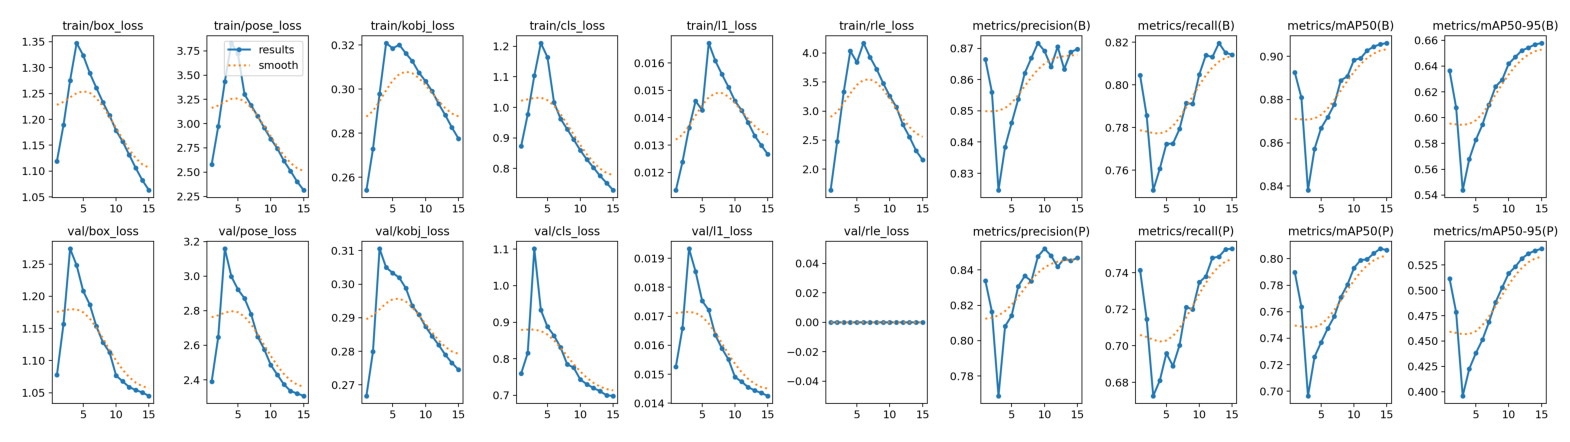

In [ ]:
# ==========================================
# 4. สรุปผลประสิทธิภาพ และแสดงกราฟ (Loss, Precision, Recall, mAP)
# ==========================================
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path

print("🔍 กำลังค้นหากราฟผลลัพธ์ที่ YOLO สร้างไว้...")
# สแกนหาไฟล์ results.png ทั่วทั้ง Colab
results_imgs = list(Path("/content/").rglob("results.png"))

if not results_imgs:
    print("❌ ไม่พบรูปกราฟผลลัพธ์")
else:
    latest_res = max(results_imgs, key=os.path.getmtime)
    print(f"📊 เจอกราฟผลลัพธ์ที่: {latest_res}\n")

    img = cv2.imread(str(latest_res))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(20, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [ ]:
# ==========================================
# 5. นำออกโมเดล (Export) & สำรองข้อมูลขึ้น Google Drive
# ==========================================
import os
import shutil
from pathlib import Path
from ultralytics import YOLO

print("🔍 กำลังสแกนหาไฟล์โมเดลที่ดีที่สุด (best.pt)...")
all_best_pts = [p for p in Path("/content/").rglob("best.pt") if "drive" not in str(p)]

if not all_best_pts:
    print("❌ ไม่พบไฟล์ best.pt เลยครับ")
else:
    latest_best_pt = max(all_best_pts, key=os.path.getmtime)
    print(f"🎯 เจอโมเดลล่าสุดแล้วที่: {latest_best_pt}")

    print("🤖 โหลดโมเดลเพื่อทำการแปลงไฟล์...")
    best_model = YOLO(latest_best_pt)

    print("⚙️ กำลังแปลงโมเดลเป็น .onnx สำหรับ Local Production...")
    onnx_path = best_model.export(format="onnx", imgsz=640)
    print(f"✅ แปลงไฟล์ ONNX สำเร็จ!\n")

    # สำรองไฟล์เข้า Google Drive
    save_model_dir = "/content/drive/MyDrive/CPE-306/models/yolo_body"
    os.makedirs(save_model_dir, exist_ok=True)

    shutil.copy(latest_best_pt, save_model_dir)
    shutil.copy(onnx_path, save_model_dir)

    print(f"🎉 สำเร็จทุกขั้นตอน! ไฟล์ .pt และ .onnx ถูกเซฟอย่างปลอดภัยใน Google Drive แล้วที่:")
    print(f"👉 {save_model_dir}")

🔍 กำลังสแกนหาไฟล์โมเดลที่ดีที่สุด (best.pt)...
🎯 เจอโมเดลล่าสุดแล้วที่: /content/runs/pose/VTuber_Body/YOLO26_Train/weights/best.pt
🤖 โหลดโมเดลเพื่อทำการแปลงไฟล์...
⚙️ กำลังแปลงโมเดลเป็น .onnx สำหรับ Local Production...
Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26n-pose summary (fused): 129 layers, 2,926,494 parameters, 0 gradients, 7.6 GFLOPs

PyTorch: starting from '/content/runs/pose/VTuber_Body/YOLO26_Train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 56, 8400) (7.4 MB)

ONNX: starting export with onnx 1.23.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 1.7s, saved as '/content/runs/pose/VTuber_Body/YOLO26_Train/weights/best.onnx' (11.6 MB)

Export complete (2.1s)
Results saved to /content/runs/pose/VTuber_Body/YOLO26_Train/weights/best.onnx
Predict:         yolo predict task=pose model=/content/runs/pose/VTuber_Body/YOLO26_Train/weights/best.onnx imgsz=640 
Validate:   

In [ ]:
# ==========================================
# 6. พิมพ์สรุปผลตัวเลข (Text Summary) จาก YOLO
# ==========================================
import pandas as pd
import os
from pathlib import Path

print("🔍 กำลังดึงตัวเลขสถิติจากรอบการเทรนสุดท้าย...")
# สแกนหาไฟล์ results.csv ที่ YOLO สร้างไว้
csv_files = list(Path("/content/").rglob("results.csv"))

if not csv_files:
    print("❌ ไม่พบไฟล์บันทึกสถิติ (results.csv)")
else:
    latest_csv = max(csv_files, key=os.path.getmtime)

    # อ่านไฟล์ CSV ด้วย Pandas
    df = pd.read_csv(latest_csv)
    df.columns = df.columns.str.strip() # ลบช่องว่างส่วนเกินที่ชื่อคอลัมน์

    # ดึงข้อมูลแถวสุดท้าย (รอบเทรนล่าสุด)
    final_row = df.iloc[-1]
    epoch_num = int(final_row['epoch'])

    # ค้นหาคอลัมน์ความแม่นยำ (mAP) อย่างปลอดภัย
    pose_map_col = [c for c in df.columns if 'mAP50(P)' in c or 'mAP50(p)' in c]
    box_map_col = [c for c in df.columns if 'mAP50(B)' in c or 'mAP50(b)' in c]

    pose_map = final_row[pose_map_col[0]] * 100 if pose_map_col else 0
    box_map = final_row[box_map_col[0]] * 100 if box_map_col else 0

    # ปริ้นท์ผลลัพธ์
    print("\n" + "="*55)
    print(f"🏆 สรุปประสิทธิภาพ YOLO11-Pose (ผ่านไป {epoch_num} Epochs) 🏆")
    print("="*55)
    print(f"  🎯 ความแม่นยำในการจับจุดร่างกาย (Pose mAP50) : {pose_map:.2f}%")
    print(f"  📦 ความแม่นยำในการสร้างกรอบภาพ (Box mAP50)   : {box_map:.2f}%")
    print("="*55)
    print("💡 หมายเหตุ: ในงานระดับโลกของ YOLO จะใช้ค่า mAP50 เป็นมาตรฐาน\n             ใช้อ้างอิงเป็นค่า Accuracy ของโมเดลได้เลยครับ")

🔍 กำลังดึงตัวเลขสถิติจากรอบการเทรนสุดท้าย...

🏆 สรุปประสิทธิภาพ YOLO11-Pose (ผ่านไป 15 Epochs) 🏆
  🎯 ความแม่นยำในการจับจุดร่างกาย (Pose mAP50) : 80.66%
  📦 ความแม่นยำในการสร้างกรอบภาพ (Box mAP50)   : 90.61%
💡 หมายเหตุ: ในงานระดับโลกของ YOLO จะใช้ค่า mAP50 เป็นมาตรฐาน
             ใช้อ้างอิงเป็นค่า Accuracy ของโมเดลได้เลยครับ
